In [1]:
%load_ext autoreload
%cd /workdir/ComfyUI/
%autoreload 2

/workdir/ComfyUI


In [2]:
from custom_nodes.comfywr_pytorch_renderkit.meshes.cuboid import Cuboid
from custom_nodes.comfywr_pytorch_renderkit.meshes.roofed_building import RoofedBuilding
from custom_nodes.comfywr_pytorch_renderkit.cameras.parametric_camera import ParametricCamera
from custom_nodes.comfywr_pytorch_renderkit.transforms.transform import Transform

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch
import numpy as np
from PIL import Image
from pytorch3d.renderer import MeshRasterizer, RasterizationSettings, SoftSilhouetteShader, MeshRenderer

import matplotlib.pyplot as plt

In [4]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import gaussian_blur

In [5]:
def ensure_batch(tensor):
    """Ensure tensor is 4D: (B, C, H, W)"""
    if tensor.ndim == 3:
        return tensor.unsqueeze(0)
    return tensor


def sobel_filter(tensor):
    """
    Computes Sobel gradients in x and y directions using a single convolution.
    Returns: grad_x, grad_y (B, C, H, W)
    """
    B, C, H, W = tensor.shape
    device = tensor.device

    # Define Sobel kernels for x and y (2, 1, 3, 3)
    sobel_kernel = torch.tensor([
        [[1, 0, -1], [2, 0, -2], [1, 0, -1]],  # dx
        [[1, 2, 1], [0, 0, 0], [-1, -2, -1]]   # dy
    ], dtype=torch.float32, device=device).unsqueeze(1) / 8.0

    # Repeat for each channel
    kernel = sobel_kernel.repeat(C, 1, 1, 1)  # (2*C, 1, 3, 3)
    input_reshaped = tensor.view(B * C, 1, H, W)
    out = F.conv2d(input_reshaped, kernel, padding=1, groups=1)  # (B*C, 2, H, W)
    out = out.view(B, C, 2, H, W)

    grad_x = out[:, :, 0, :, :]
    grad_y = out[:, :, 1, :, :]
    return grad_x, grad_y


def compute_normal_map(depth: torch.Tensor, alpha: torch.Tensor,
                        blur_kernel_size=5, blur_sigma=1.0):
    # Ensure batch dimensions
    depth = ensure_batch(depth)
    alpha = ensure_batch(alpha)

    B, _, H, W = depth.shape

    # Blur depth and alpha using torchvision
    blurred_depth = gaussian_blur(depth, kernel_size=blur_kernel_size, sigma=blur_sigma)
    # blurred_alpha = gaussian_blur(alpha, kernel_size=blur_kernel_size, sigma=blur_sigma)

    # Compute gradients
    dzdx, dzdy = sobel_filter(blurred_depth)

    # Construct normal components
    nx = -dzdx
    ny = -dzdy
    nz = torch.ones_like(dzdx) / W

    # Stack normals and normalize
    normal = torch.cat([nx, ny, nz], dim=1)  # (B, 3, H, W)
    normal = F.normalize(normal, dim=1)

    # Apply alpha mask directly
    normal = normal * (alpha > 0.5).float()

    return normal

In [6]:
import torch
from pytorch3d.renderer import SoftSilhouetteShader, BlendParams, softmax_rgb_blend
from pytorch3d.renderer.mesh.shading import interpolate_face_attributes

from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader

In [7]:
depth_path = "../ComfyUI/output/building_masked_depth_00003_.png"

invalid_depth_weight = 1e-6

depth_size = (128,128)

# Load depth map and mask
depth_img = np.array(Image.open(depth_path).resize(depth_size))
alpha = depth_img[:,:,-1]
depth = torch.from_numpy(depth_img[...,-2:]/255)
alpha = depth[:,:,-1]
dmin, dmax = torch.aminmax(depth.select(-1,0)[depth.select(-1,1) > 0])

normalized_depth = depth.clone()
normalized_depth.select(-1,0).sub_(dmin).div_(dmax-dmin).mul_(depth.select(-1,1)).sub_(1).add_(depth.select(-1,1), alpha=1)
normalized_depth.select(-1,0).clamp_min_(-invalid_depth_weight)

tensor([[-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        ...,
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06],
        [-1.0000e-06, -1.0000e-06, -1.0000e-06,  ..., -1.0000e-06,
         -1.0000e-06, -1.0000e-06]], dtype=torch.float64)

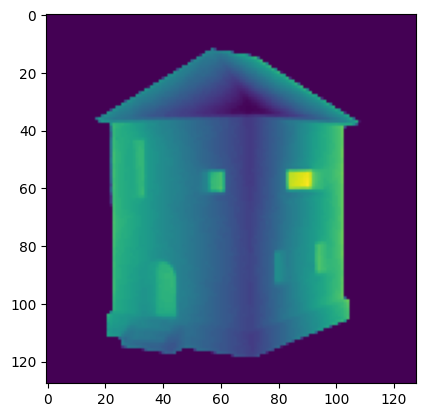

In [8]:
plt.imshow(normalized_depth.select(-1,0))

In [9]:
normalized_depth.amin()

tensor(-1.0000e-06, dtype=torch.float64)

In [10]:
ndepth, nalpha = normalized_depth.permute(2,0,1).float().unflatten(0,(-1,1,1))
normalmap = compute_normal_map(ndepth, nalpha, blur_kernel_size=3, blur_sigma=0.15)
normalmap = gaussian_blur(normalmap, kernel_size=5)
normalmap_rgb = normalmap.add(1).div_(2).mul_(nalpha)#.squeeze().permute(1,2,0)
normalmap_rgba = torch.cat([normalmap_rgb, nalpha], dim=1)

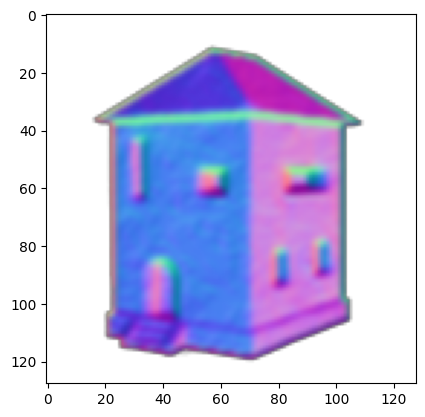

In [11]:
plt.imshow(normalmap_rgba.squeeze().permute(1,2,0))

In [12]:
normalmap_rgb.aminmax()

torch.return_types.aminmax(
min=tensor(0.),
max=tensor(0.9749))

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
depth = depth.to(device)

In [14]:
device

device(type='cuda')

In [15]:
# Rasterization settings for silhouette rendering  
sigma = 1e-6
raster_settings_silhouette = RasterizationSettings(
    image_size=depth.shape[:2], 
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma, 
    faces_per_pixel=5, 
)

# Silhouette renderer 
renderer_normalized_depth = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteWithDepthShader(normalize_depth=True, invalid_depth_weight=1e-6)
)

# Normal Map renderer
renderer_normalmap = MeshRenderer(
    rasterizer=MeshRasterizer(
        raster_settings=raster_settings_silhouette
    ),
    shader=NormalsWithSoftSilhouetteShader(camera_relative=True)
)

rasterizer_silhouette = MeshRasterizer(raster_settings=raster_settings_silhouette)

In [16]:
# Initialize models
transform = Transform(lock_scale=True, lock_rotation=True, lock_translation=True)

# sizes = torch.tensor([3., 2., 6.])
sizes = torch.tensor([3.5, 4, 4.5])
sizes /= sizes.max()

roof_size = (.05, 0.3, 0.2)

lr = 3e-4

fov = 30
distance = 3
# azimuth = 299.0
# elev = 13

azimuth = 38.0
elev = 3.0



camera = ParametricCamera(fov=fov, dist=distance, azim=azimuth, elev=elev, dist_range=(2,10.), fov_range=(30,80)).to(device)
# cuboid = Cuboid(*sizes, transform=transform).to(device)
cuboid = RoofedBuilding(*sizes, roof_size=roof_size,transform=transform).to(device)

# Rasterizer setup
raster_settings = RasterizationSettings(
    image_size=depth.shape[:2], blur_radius=0.0, faces_per_pixel=1
)
rasterizer = MeshRasterizer(raster_settings=raster_settings)

In [17]:
from custom_nodes.comfywr_pytorch_renderkit.shaders.depth_with_soft_silhouette import SoftSilhouetteWithDepthShader
from custom_nodes.comfywr_pytorch_renderkit.shaders.normals_with_soft_silhouette import NormalsWithSoftSilhouetteShader

mesh = cuboid()
cams = camera(device)
rendered_normalmap = renderer_normalmap(meshes_world=mesh, cameras=cams)
rendered_normalized_depth = renderer_normalized_depth(meshes_world=mesh, cameras=cams)

fragments = rasterizer_silhouette(meshes_world=mesh, cameras=cams)

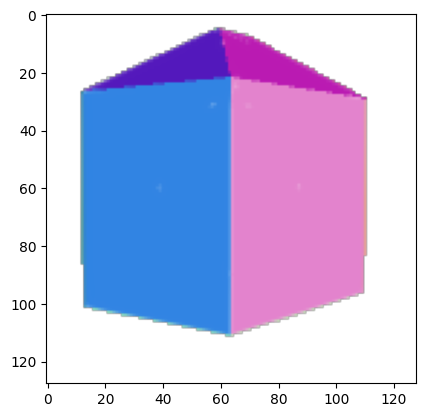

In [18]:
plt.imshow(rendered_normalmap.squeeze().detach().cpu())

torch.Size([1, 128, 128, 2])


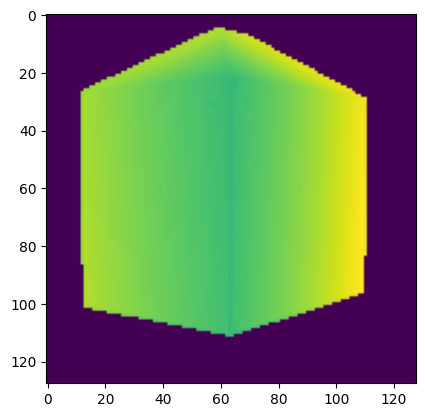

In [19]:
plt.imshow(rendered_normalized_depth[...,0].squeeze().detach().cpu())
print(rendered_normalized_depth.shape)

In [20]:
from custom_nodes.comfywr_pytorch_renderkit.optimizations.normalmap_optimization import optimize_mesh_normalmap

target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

# SGD optimizer: translation (inside transform), sizes, and camera params
params = list(cuboid.parameters()) + list(camera.parameters())
# params = camera.parameters()
# optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9)
optimizer = torch.optim.AdamW(params, lr=lr)

mesh, camera, losses, best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 150, early_stop_percent=1e-5, silhouette_weight=4.0, device=device)
mesh, camera, further_losses, best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, silhouette_weight=4.0, device=device)
masked_target_normalmap = target_normalmap * best_render.select(-1,-1).unsqueeze(-1).gt(0)
params = list(cuboid.parameters())
optimizer = torch.optim.AdamW(params, lr=lr)
mesh, camera, masked_losses, masked_best_render = optimize_mesh_normalmap(cuboid, camera, renderer_normalmap, masked_target_normalmap, optimizer, early_stop_window = 200, early_stop_percent=1e-5, silhouette_weight=1.0, device=device)

 15%|████████████████████▎                                                                                                                | 459/3000 [00:06<00:35, 71.41it/s]


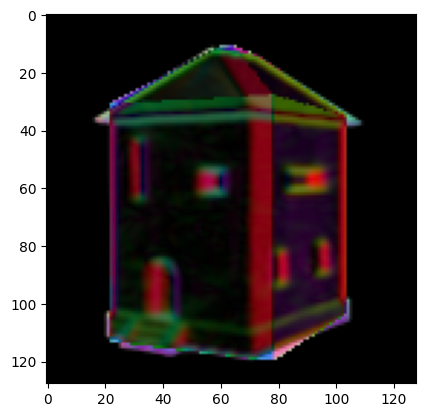

In [21]:
silhs = (masked_best_render - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

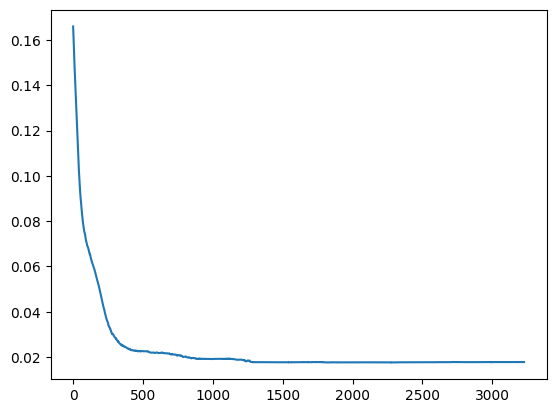

In [22]:
plt.plot(losses+further_losses)

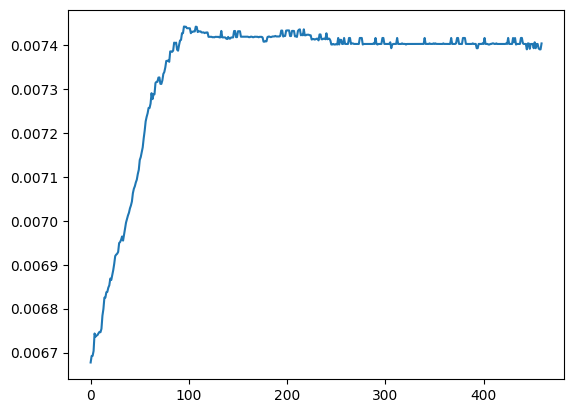

In [23]:
plt.plot(masked_losses)

In [24]:
denorm = lambda n, mn, mx: mn + n * (mx - mn)
camera.fov

tensor([[29.9914]], device='cuda:0')

In [25]:
cuboid.roof_size

Parameter containing:
tensor([0.0978, 0.2685, 0.2708], device='cuda:0', requires_grad=True)

In [26]:
import torch.nn as nn

translation = cuboid.transform.translation.detach()

# Create an MSE loss criterion
criterion = nn.HuberLoss(reduction='mean')

with torch.no_grad():

    # transform = Transform(translation = cuboid.transform.translation.detach(), lock_scale=True, lock_rotation=True)
    # transform.translation[:] = cuboid.transform.translation.detach()
    new_cuboid = RoofedBuilding(*cuboid.sizes, roof_size=tuple(cuboid.roof_size)).to(device)

    new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)
    
    x = 0.038
    new_cuboid.sizes[1] -= x
    new_cuboid.transform.translation[1] -= x - 0.01
    new_cuboid.roof_size[1] += 0.068
    new_cuboid.roof_size[2] += 0.18
    # Render the cuboid
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

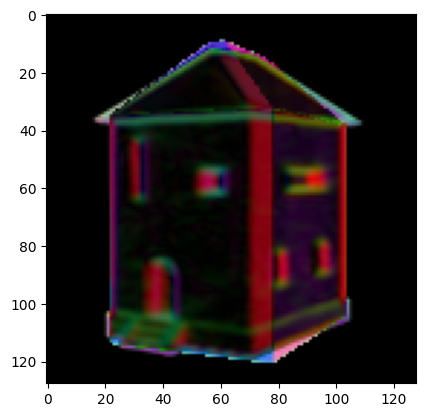

In [27]:
silhs = (new_rendered - target_normalmap)[0,...,:-1].abs()
plt.imshow(silhs.detach().cpu())

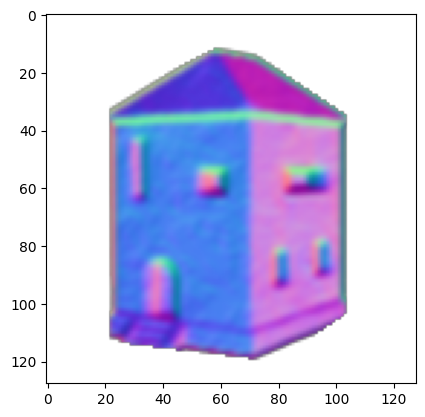

In [28]:
plt.imshow(masked_target_normalmap.squeeze().detach().cpu())

In [29]:
new_target_normalmap = normalmap_rgba.permute(0,2,3,1).float().to(device)

with torch.no_grad():
    mesh = new_cuboid()
    cams = camera(device)
    new_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * new_rendered[...,-1].unsqueeze(-1).gt(0)
    new_loss = criterion(new_rendered, masked_target_normalmap)
    mesh = cuboid()
    old_rendered = renderer_normalmap(meshes_world=mesh, cameras=cams)
    masked_target_normalmap = new_target_normalmap * old_rendered[...,-1].unsqueeze(-1).gt(0)
    old_loss = criterion(old_rendered, masked_target_normalmap)

tensor([[[0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000]],

        [[0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000]],

        [[0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000]],

        [[0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000],
         [0.2856, 0.5137, 0.9515, 1.0000]]])


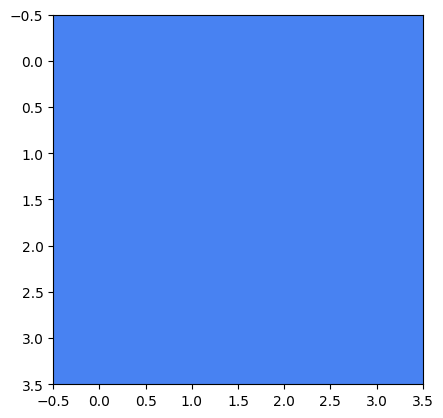

In [30]:
patch = new_rendered.squeeze().detach().cpu()[78:82,58:62]

plt.imshow(patch)
print(patch)

In [31]:
new_loss.item(),old_loss.item()

(0.00715327775105834, 0.006685145664960146)

In [32]:
c = cuboid.cuboid()

In [33]:
c.sizes

Parameter containing:
tensor([0.7093, 0.9673, 0.9398], device='cuda:0', requires_grad=True)

In [40]:
trimesh_cuboid = cuboid.export_trimesh()
trimesh_cuboid.faces
# trimesh_cuboid.vertex_normals = -trimesh_cuboid.vertex_normals

TrackedArray([[ 0,  1,  2],
              [ 0,  2,  3],
              [ 4,  6,  5],
              [ 4,  7,  6],
              [ 8,  9, 10],
              [ 8, 10, 11],
              [12, 14, 13],
              [12, 15, 14],
              [16, 17, 18],
              [16, 18, 19],
              [20, 21, 22],
              [20, 22, 23],
              [24, 26, 25],
              [24, 27, 26],
              [28, 29, 30],
              [28, 30, 31],
              [32, 34, 33],
              [32, 35, 34],
              [36, 37, 38],
              [36, 38, 39]])

In [41]:
trimesh_cuboid.scene().show()

In [36]:
cub = c()

In [37]:
trimesh_cuboid.vertex_normals

array([[ 0.,  0.,  1.],
       [ 0.,  0.,  1.],
       [ 0.,  0.,  1.],
       [ 0.,  0.,  1.],
       [ 0.,  0., -1.],
       [ 0.,  0., -1.],
       [ 0.,  0., -1.],
       [ 0.,  0., -1.],
       [ 0., -1.,  0.],
       [ 0., -1.,  0.],
       [ 0., -1.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  1.,  0.],
       [ 0.,  1.,  0.],
       [-1.,  0.,  0.],
       [-1.,  0.,  0.],
       [-1.,  0.,  0.],
       [-1.,  0.,  0.],
       [ 1.,  0.,  0.],
       [ 1.,  0.,  0.],
       [ 1.,  0.,  0.],
       [ 1.,  0.,  0.]])

In [38]:
cub.faces_packed().flip(-1)

tensor([[ 2,  1,  0],
        [ 3,  2,  0],
        [ 5,  6,  4],
        [ 6,  7,  4],
        [10,  9,  8],
        [11, 10,  8],
        [13, 14, 12],
        [14, 15, 12],
        [18, 17, 16],
        [19, 18, 16],
        [21, 22, 20],
        [22, 23, 20]], device='cuda:0')

In [39]:
cub.faces_packed()

tensor([[ 0,  1,  2],
        [ 0,  2,  3],
        [ 4,  6,  5],
        [ 4,  7,  6],
        [ 8,  9, 10],
        [ 8, 10, 11],
        [12, 14, 13],
        [12, 15, 14],
        [16, 17, 18],
        [16, 18, 19],
        [20, 22, 21],
        [20, 23, 22]], device='cuda:0')